# 🛡️ EPI Finder - Análise Exploratória de Dados (EDA) e Pipeline de Visão Computacional

Neste notebook, realizamos a **Fase 3** do projeto **EPI Finder**.
Os objetivos centrais desta etapa são:
1. **Auditar o Dataset:** Avaliar a qualidade das anotações, balanceamento entre classes (`with_helmet` vs `without_helmet`) e proporções dos splits.
2. **Análise com Pandas:** Calcular métricas agregadas por imagem e por objeto anotado (área, proporção, contagens).
3. **Manipulação Matricial com NumPy:** Praticar conversão de coordenadas YOLO para pixels, recorte de ROIs (Region of Interest) e implementação do **IoU (Intersection over Union)** do zero.
4. **Visualizações Gráficas:** Plotar gráficos com Matplotlib e Seaborn, além de desenhar as anotações sobre imagens reais com OpenCV.

## 1. Configuração do Ambiente e Importação de Bibliotecas
Configuramos o `sys.path` para permitir a importação modular de `src.utils` e definimos os estilos visuais dos gráficos.

In [1]:
import os
import sys
import glob
from pathlib import Path
import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Garante que a raiz do projeto esteja no sys.path e como diretório ativo
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(f'Diretório raiz do projeto: {PROJECT_ROOT}')

# Importação dos utilitários customizados do pacote src
from src.utils import (
    DEFAULT_CLASSES,
    CLASS_COLORS_BGR,
    yolo_to_xyxy,
    xyxy_to_yolo,
    compute_iou,
    compute_iou_matrix,
    extract_roi,
    bgr_to_rgb,
    normalize_image,
    draw_bounding_boxes
)

# Configurações estéticas de gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print('Bibliotecas importadas com sucesso!')

Diretório raiz do projeto: /app
Bibliotecas importadas com sucesso!


## 2. Validação do Arquivo de Configuração do Dataset (`data/data.yaml`)
O arquivo `data/data.yaml` define os caminhos e as classes reconhecidas pelo YOLOv8 da Ultralytics.

In [2]:
yaml_path = 'data/data.yaml'
with open(yaml_path, 'r', encoding='utf-8') as f:
    dataset_cfg = yaml.safe_load(f)

print('--- Configuração data.yaml ---')
for k, v in dataset_cfg.items():
    print(f'{k}: {v}')

--- Configuração data.yaml ---
path: ../data/dataset
train: train/images
val: valid/images
test: valid/images
nc: 2
names: {0: 'with_helmet', 1: 'without_helmet'}


## 3. Varredura e Estruturação do Dataset em Pandas
Percorremos os arquivos `.txt` (formato YOLO) e as imagens correspondentes nas pastas `train` e `valid`.
Estruturamos os dados em dois DataFrames do Pandas:
1. `df_annotations`: granularidade por **caixa delimitadora** (objeto anotado).
2. `df_images`: granularidade por **imagem** (resumo de conformidade por cena).

In [3]:
base_data_dir = Path('data/dataset')
anno_rows = []
image_rows = []

for split in ['train', 'valid', 'test']:
    lbl_dir = base_data_dir / split / 'labels'
    img_dir = base_data_dir / split / 'images'
    
    if not lbl_dir.exists():
        continue
        
    label_files = sorted(list(lbl_dir.glob('*.txt')))
    for lf in label_files:
        base_stem = lf.stem
        matched_img = None
        for ext in ['.jpg', '.jpeg', '.png']:
            cand = img_dir / f'{base_stem}{ext}'
            if cand.exists():
                matched_img = str(cand)
                break
        
        with open(lf, 'r', encoding='utf-8') as f:
            lines = [l.strip() for l in f if l.strip()]
            
        wh_count = 0
        woh_count = 0
        
        for line in lines:
            tokens = line.split()
            cls_id = int(tokens[0])
            xc, yc, w, h = map(float, tokens[1:5])
            
            if cls_id == 0:
                wh_count += 1
            elif cls_id == 1:
                woh_count += 1
                
            anno_rows.append({
                'split': split,
                'image_name': Path(matched_img).name if matched_img else base_stem,
                'image_path': matched_img,
                'class_id': cls_id,
                'class_name': DEFAULT_CLASSES.get(cls_id, f'unknown_{cls_id}'),
                'x_center': xc,
                'y_center': yc,
                'width': w,
                'height': h,
                'area': w * h,
                'aspect_ratio': w / (h + 1e-6)
            })
            
        image_rows.append({
            'split': split,
            'image_name': Path(matched_img).name if matched_img else base_stem,
            'image_path': matched_img,
            'total_boxes': len(lines),
            'with_helmet': wh_count,
            'without_helmet': woh_count,
            'has_infraction': woh_count > 0
        })

df_annotations = pd.DataFrame(anno_rows)
df_images = pd.DataFrame(image_rows)

print(f'Total de imagens registradas: {len(df_images)}')
print(f'Total de caixas anotadas: {len(df_annotations)}')
df_annotations.head()

Total de imagens registradas: 442
Total de caixas anotadas: 623


,split,image_name,image_path,class_id,class_name,x_center,y_center,width,height,area,aspect_ratio
0,train,WhatsApp-Image-2026-05-29-at-15-11-27_jpeg.rf....,data/dataset/train/images/WhatsApp-Image-2026-...,0,with_helmet,0.260937,0.439063,0.350000,0.479687,0.167891,0.729640
1,train,WhatsApp-Image-2026-05-29-at-15-11-28_jpeg.rf....,data/dataset/train/images/WhatsApp-Image-2026-...,0,with_helmet,0.192188,0.370312,0.237500,0.329688,0.078301,0.720377
2,train,WhatsApp-Image-2026-05-29-at-15-11-28_jpeg.rf....,data/dataset/train/images/WhatsApp-Image-2026-...,0,with_helmet,0.470313,0.517188,0.295312,0.420312,0.124124,0.702601
3,train,frame00951_png.rf.e6baceee9faa22a6ca176fcd0d89...,data/dataset/train/images/frame00951_png.rf.e6...,0,with_helmet,0.475000,0.362500,0.115625,0.162500,0.018789,0.711534
4,train,frame01051_png.rf.bea76801d14611abbe9bee35aed7...,data/dataset/train/images/frame01051_png.rf.be...,0,with_helmet,0.487500,0.359375,0.109375,0.156250,0.017090,0.699996


## 4. Análise Estatística e Auditoria de Dados (Pandas)
Examinamos as tabelas de agregação do dataset para quantificar volume, distribuição por split e o desbalanceamento de classes.

In [4]:
print('=== DISTRIBUIÇÃO DE IMAGENS POR SPLIT ===')
img_split_dist = df_images['split'].value_counts().rename_axis('Split').reset_index(name='Qtd_Imagens')
img_split_dist['Percentual (%)'] = (img_split_dist['Qtd_Imagens'] / len(df_images)) * 100
display(img_split_dist)

print('\n=== DISTRIBUIÇÃO DE CLASSES (GERAL) ===')
cls_dist = df_annotations['class_name'].value_counts().rename_axis('Classe').reset_index(name='Instâncias')
cls_dist['Percentual (%)'] = (cls_dist['Instâncias'] / len(df_annotations)) * 100
display(cls_dist)

print('\n=== DISTRIBUIÇÃO DE CLASSES POR SPLIT ===')
split_cls_table = pd.crosstab(df_annotations['split'], df_annotations['class_name'], margins=True)
display(split_cls_table)

=== DISTRIBUIÇÃO DE IMAGENS POR SPLIT ===


,Split,Qtd_Imagens,Percentual (%)
0,train,354,80.090498
1,valid,88,19.909502



=== DISTRIBUIÇÃO DE CLASSES (GERAL) ===


,Classe,Instâncias,Percentual (%)
0,with_helmet,590,94.70305
1,without_helmet,33,5.29695



=== DISTRIBUIÇÃO DE CLASSES POR SPLIT ===


class_name,with_helmet,without_helmet,All
split,,,
train,481,27,508
valid,109,6,115
All,590,33,623


### 4.1. Análise de Conformidade e Infrações por Imagem
Identificamos a proporção de imagens que contêm pelo menos uma pessoa sem capacete (`without_helmet`).

In [5]:
infr_summary = df_images['has_infraction'].value_counts().rename_axis('Possui_Infracao').reset_index(name='Qtd_Imagens')
infr_summary['Significado'] = infr_summary['Possui_Infracao'].map({False: 'Apenas Pessoas com Capacete', True: 'Pelo Menos 1 Sem Capacete'})
infr_summary['Percentual (%)'] = (infr_summary['Qtd_Imagens'] / len(df_images)) * 100
display(infr_summary)

,Possui_Infracao,Qtd_Imagens,Significado,Percentual (%)
0,False,409,Apenas Pessoas com Capacete,92.533937
1,True,33,Pelo Menos 1 Sem Capacete,7.466063


### 4.2. Estatísticas Descritivas das Caixas Delimitadoras (Tamanho e Proporção)

In [6]:
print('=== ESTATÍSTICAS DAS CAIXAS (LARGURA, ALTURA, ÁREA E ASPECT RATIO) ===')
display(df_annotations[['width', 'height', 'area', 'aspect_ratio']].describe().T)

=== ESTATÍSTICAS DAS CAIXAS (LARGURA, ALTURA, ÁREA E ASPECT RATIO) ===


,count,mean,std,min,25%,50%,75%,max
width,623.0,0.134365,0.071892,0.045312,0.082812,0.106250,0.171875,0.431250
height,623.0,0.157700,0.083063,0.053125,0.098437,0.128125,0.185938,0.479687
area,623.0,0.026917,0.030655,0.002478,0.008163,0.013188,0.031440,0.194736
aspect_ratio,623.0,0.855191,0.111360,0.646014,0.754108,0.863628,0.956101,1.425527


## 5. Visualizações Gráficas (Matplotlib & Seaborn)
Geramos gráficos analíticos para diagnóstico visual da distribuição de classes, densidade por imagem e tamanhos.

/tmp/ipykernel_137/1337688431.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cls_dist, x='Classe', y='Instâncias', ax=axes[0], palette=['#2ecc71', '#e74c3c'])


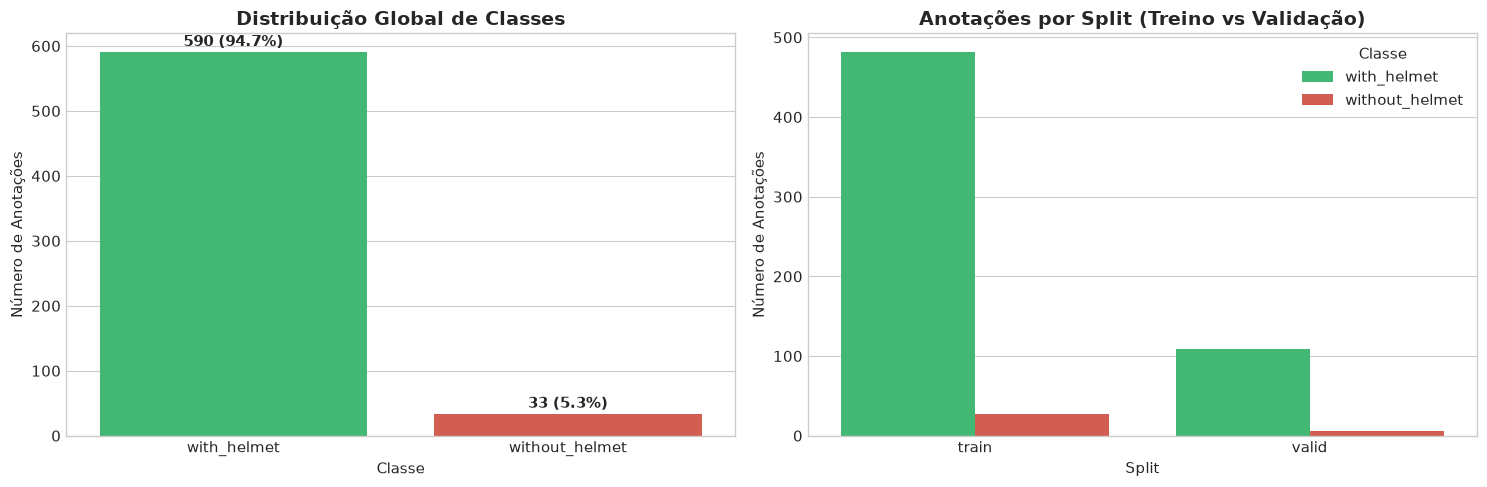

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Contagem Geral de Classes
sns.barplot(data=cls_dist, x='Classe', y='Instâncias', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribuição Global de Classes', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Número de Anotações')
for idx, row in cls_dist.iterrows():
    axes[0].text(idx, row['Instâncias'] + 10, f"{row['Instâncias']} ({row['Percentual (%)']:.1f}%)", ha='center', fontweight='bold')

# 2. Distribuição por Split
split_plot_df = df_annotations.groupby(['split', 'class_name']).size().reset_index(name='contagem')
sns.barplot(data=split_plot_df, x='split', y='contagem', hue='class_name', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Anotações por Split (Treino vs Validação)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Número de Anotações')
axes[1].set_xlabel('Split')
axes[1].legend(title='Classe')

plt.tight_layout()
plt.show()

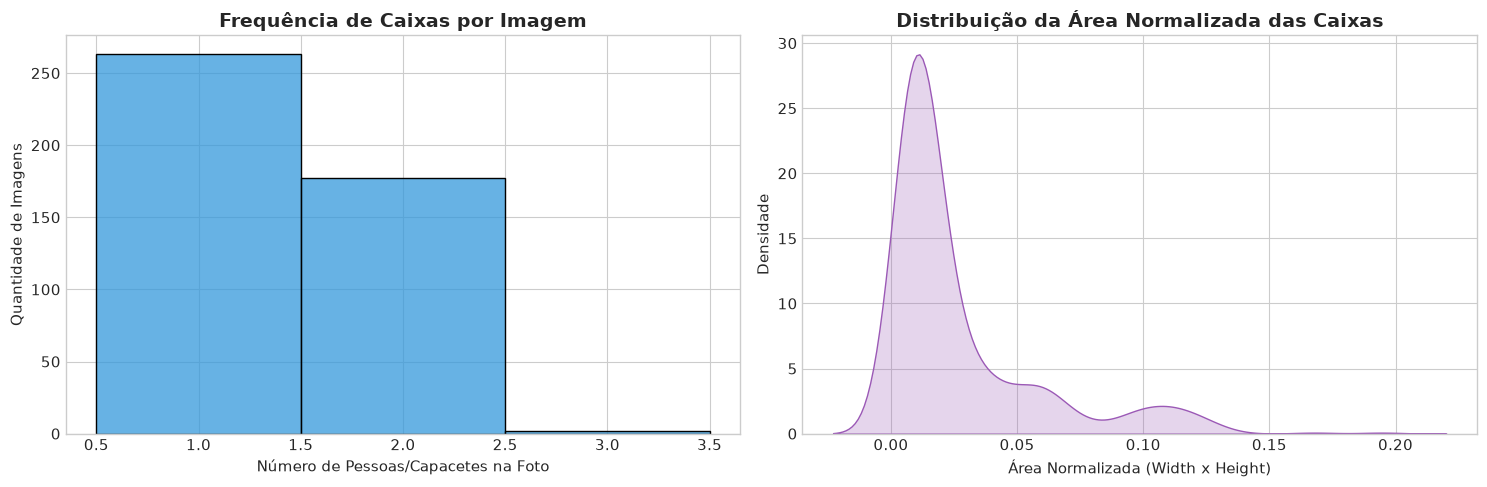

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 3. Quantidade de Pessoas por Imagem
sns.histplot(df_images['total_boxes'], bins=range(1, int(df_images['total_boxes'].max()) + 2), discrete=True, ax=axes[0], color='#3498db', kde=False)
axes[0].set_title('Frequência de Caixas por Imagem', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Número de Pessoas/Capacetes na Foto')
axes[0].set_ylabel('Quantidade de Imagens')

# 4. Distribuição das Áreas das Caixas (Tamanho dos Objetos)
sns.kdeplot(df_annotations['area'], fill=True, color='#9b59b6', ax=axes[1])
axes[1].set_title('Distribuição da Área Normalizada das Caixas', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Área Normalizada (Width x Height)')
axes[1].set_ylabel('Densidade')

plt.tight_layout()
plt.show()

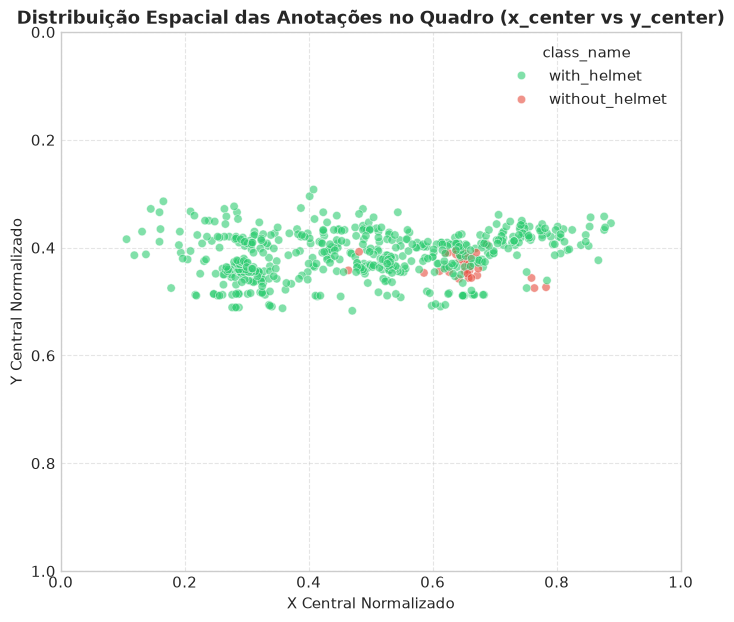

In [9]:
# 5. Distribuição Espacial dos Centros (x_center vs y_center)
plt.figure(figsize=(8, 7))
sns.scatterplot(
    data=df_annotations,
    x='x_center',
    y='y_center',
    hue='class_name',
    alpha=0.6,
    palette=['#2ecc71', '#e74c3c']
)
plt.title('Distribuição Espacial das Anotações no Quadro (x_center vs y_center)', fontsize=13, fontweight='bold')
plt.xlabel('X Central Normalizado')
plt.ylabel('Y Central Normalizado')
plt.xlim(0, 1)
plt.ylim(1, 0) # Invertido para refletir coordenadas de imagem
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 6. Prática de Visão Computacional com NumPy
Nesta seção, exercitamos as operações matriciais fundamentais de Visão Computacional:
- Conversão de coordenadas normalizadas YOLO para coordenadas de pixel.
- Extração de Região de Interesse (ROI) via fatiamento (slicing) direto: `img[y1:y2, x1:x2]`.
- Conversão BGR para RGB com fatiamento: `img[:, :, ::-1]`.
- Normalização numérica dos pixels para o intervalo $[0.0, 1.0]$.
- Implementação matemática vetorizada do **IoU (Intersection over Union)**.

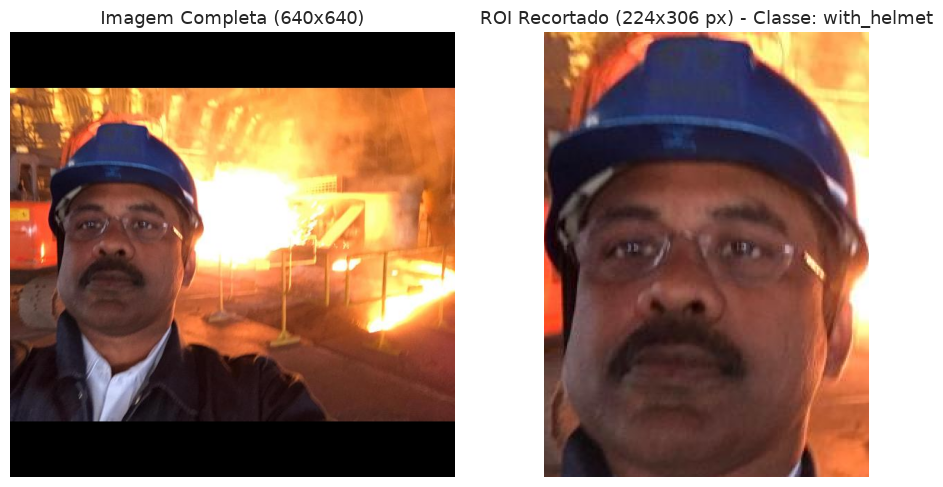

Pixels da ROI normalizados: tipo=float32, min=0.00, max=1.00


In [10]:
# Escolhe uma imagem de exemplo com anotação
sample_row = df_annotations[df_annotations['class_id'] == 0].iloc[0]
sample_img_bgr = cv2.imread(sample_row['image_path'])
h_img, w_img, c_img = sample_img_bgr.shape

# Converte coordenada YOLO para pixel
x1, y1, x2, y2 = yolo_to_xyxy(
    sample_row['x_center'],
    sample_row['y_center'],
    sample_row['width'],
    sample_row['height'],
    w_img, h_img
)

# Recorte de ROI via slicing NumPy: img[y1:y2, x1:x2]
roi_bgr = extract_roi(sample_img_bgr, (x1, y1, x2, y2))

# Conversão de canais BGR -> RGB via slicing NumPy: img[:, :, ::-1]
sample_img_rgb = bgr_to_rgb(sample_img_bgr)
roi_rgb = bgr_to_rgb(roi_bgr)

# Normalização de pixels para [0.0, 1.0] (float32)
roi_normalized = normalize_image(roi_rgb)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sample_img_rgb)
axes[0].set_title(f'Imagem Completa ({w_img}x{h_img})')
axes[0].axis('off')

axes[1].imshow(roi_rgb)
axes[1].set_title(f"ROI Recortado ({roi_rgb.shape[1]}x{roi_rgb.shape[0]} px) - Classe: {sample_row['class_name']}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'Pixels da ROI normalizados: tipo={roi_normalized.dtype}, min={roi_normalized.min():.2f}, max={roi_normalized.max():.2f}')

In [11]:
box_ground_truth = np.array([50, 50, 200, 200])
box_prediction_boa = np.array([60, 55, 205, 195])
box_prediction_ruim = np.array([150, 150, 300, 300])
box_sem_sobreposicao = np.array([300, 300, 450, 450])

iou_boa = compute_iou(box_ground_truth, box_prediction_boa)
iou_ruim = compute_iou(box_ground_truth, box_prediction_ruim)
iou_zero = compute_iou(box_ground_truth, box_sem_sobreposicao)

print(f'IoU Predição Quase Perfeita: {iou_boa:.4f}')
print(f'IoU Predição com Sobreposição Parcial: {iou_ruim:.4f}')
print(f'IoU Sem Nenhuma Sobreposição: {iou_zero:.4f}')

IoU Predição Quase Perfeita: 0.8448
IoU Predição com Sobreposição Parcial: 0.0588
IoU Sem Nenhuma Sobreposição: 0.0000


## 7. Visualização de Amostras Anotadas do Dataset
Desenhamos as caixas delimitadoras reais em imagens do dataset:
- 🟢 **Verde:** `with_helmet` (Conforme)
- 🔴 **Vermelho:** `without_helmet` (Alerta / Infração)

/tmp/ipykernel_137/2219528572.py:33: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_137/2219528572.py:33: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


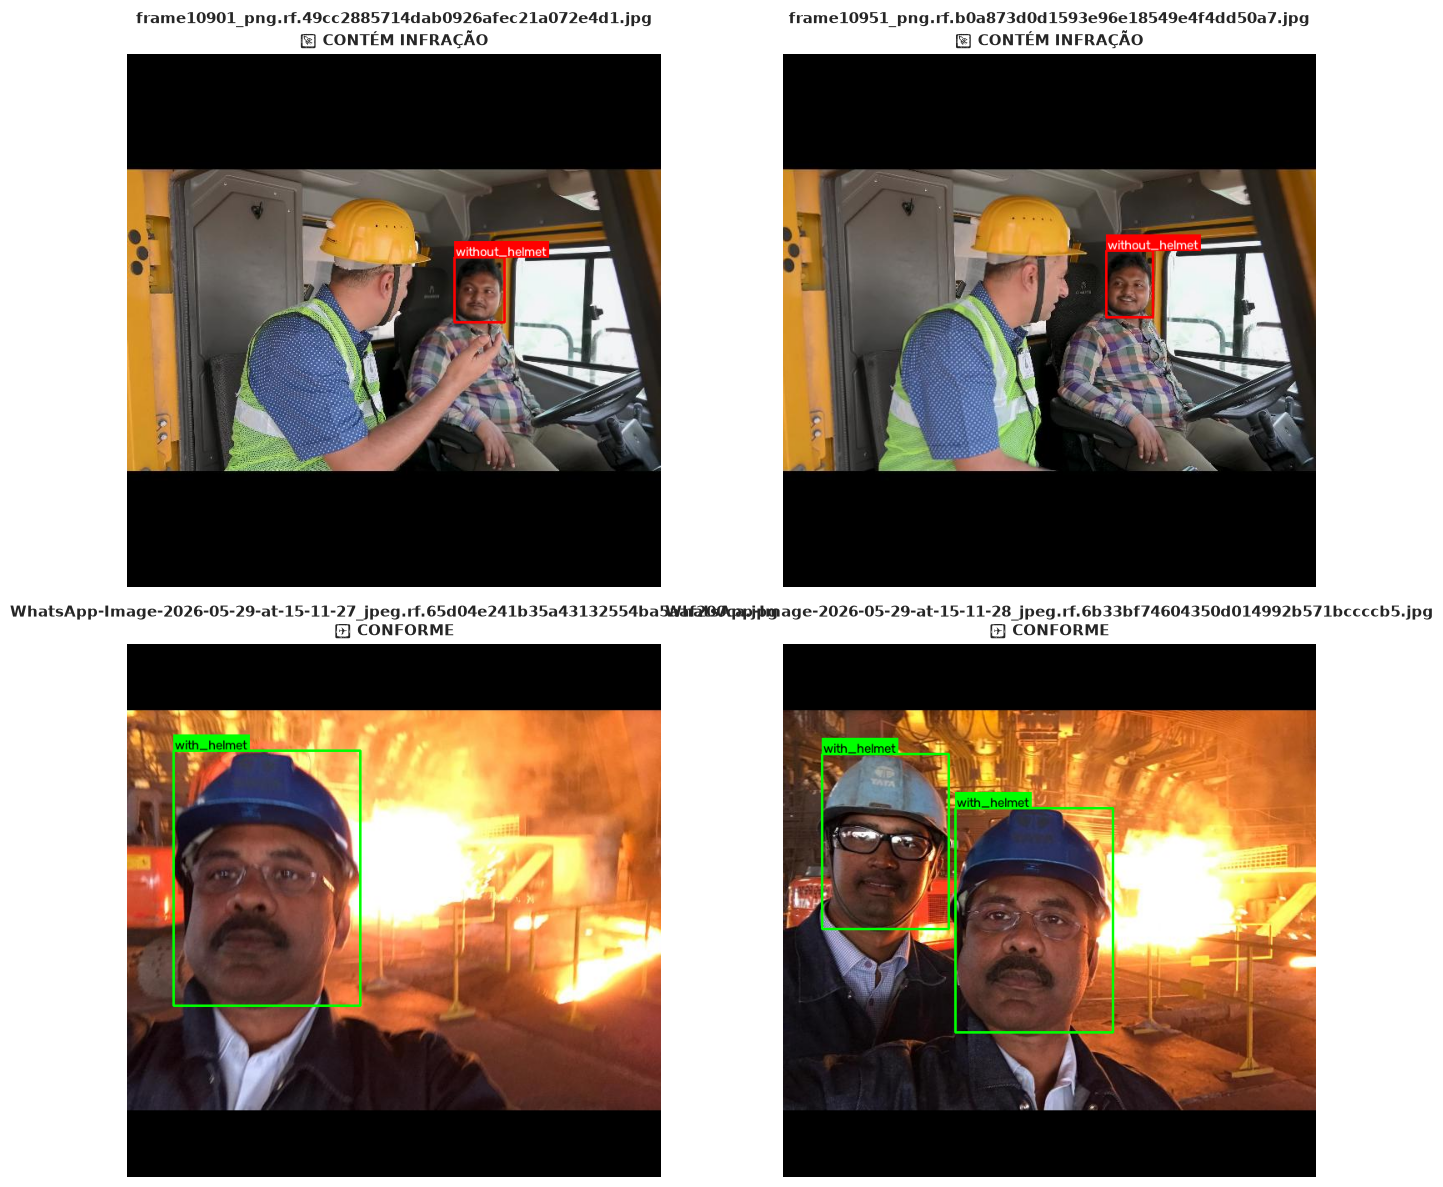

In [12]:
# Selecionamos imagens com infração (sem capacete) e sem infração para demonstração
infra_imgs = df_images[df_images['has_infraction']]['image_name'].head(2).tolist()
safe_imgs = df_images[~df_images['has_infraction']]['image_name'].head(2).tolist()
sample_names = infra_imgs + safe_imgs

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, img_name in enumerate(sample_names):
    sub_df = df_annotations[df_annotations['image_name'] == img_name]
    img_path = sub_df.iloc[0]['image_path']
    
    bgr = cv2.imread(img_path)
    h, w = bgr.shape[:2]
    
    boxes_xyxy = []
    class_ids = []
    
    for _, row in sub_df.iterrows():
        b_xyxy = yolo_to_xyxy(row['x_center'], row['y_center'], row['width'], row['height'], w, h)
        boxes_xyxy.append(b_xyxy)
        class_ids.append(row['class_id'])
        
    annotated_bgr = draw_bounding_boxes(bgr, boxes_xyxy, class_ids)
    annotated_rgb = bgr_to_rgb(annotated_bgr)
    
    axes[i].imshow(annotated_rgb)
    has_inf = any(c == 1 for c in class_ids)
    status_title = '🚨 CONTÉM INFRAÇÃO' if has_inf else '✅ CONFORME'
    axes[i].set_title(f'{img_name}\n{status_title}', fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 8. Diagnóstico Final e Recomendações Estratégicas para a Fase 4

### 🔍 Principais Achados:
1. **Volume Total:** 442 imagens (354 Treino, 88 Validação, 0 Teste no split original).
2. **Total de Instâncias:** 623 caixas delimitadoras anotadas.
3. **Severo Desbalanceamento de Classes:**
   - `with_helmet`: 590 instâncias (**94.70%**)
   - `without_helmet`: 33 instâncias (**5.30%**)
4. **Presença em Cenas:** Apenas 33 fotos contêm operários sem capacete (7.47% do dataset).
5. **Tamanho das Caixas:** A média de ocupação é de 2.69% da área da imagem (objetos pequenos a médios, com proporção média de 0.85 — típica da anatomia da cabeça humana).

### 🎯 Impacto no Treinamento (Fase 4):
- Devido ao desbalanceamento, a acurácia geral não é uma métrica confiável. Devemos priorizar o **Recall** e o **mAP@50** especificamente na classe `without_helmet`, garantindo que nenhuma cabeça desprotegida passe despercebida.
- O pipeline de aumento de dados (*data augmentation*) do YOLOv8 (Mosaic, MixUp, Flipping) será fundamental para expandir a variedade visual dos casos raros de infração.